
# 25.7) Classificação de sentimentos com spacy 

Pré processamento do texto 

Redes Neurais Convolucionais (CNNs) são algoritmos de aprendizado profundo especializados em analisar dados visuais, como imagens e vídeos, para tarefas de visão computacional.

## Anaconda 

ambiente maq2

# Classificação de textos com spaCy

# Etapa 1: Importação e instalação das bibliotecas

In [3]:
import spacy # verificar a versão atual 
spacy.__version__  

'3.8.7'

In [4]:
# se necessário rodar
#!pip install spacy --upgrade
#!pip install spacy ==2.2.2

In [5]:
#base de dados em português
#!python -m spacy download pt_core_news_sm

queremos diferenciar a alegria e o medo:

Importando as bibliotecas

In [6]:
#!pip install seaborn

In [7]:
import pandas as pd
import string
import spacy
import random
import seaborn as sns
import numpy as np

In [8]:
#from google.colab import drive
#drive.mount('/content/drive')

# Etapa 2: Carregamento da base de dados

In [9]:
base_dados = pd.read_csv('base_treinamento.txt', encoding = 'utf-8')

In [10]:
base_dados.head() # base de dados, mas ainda não validamos. Precisamos criar a nossa própria base de dados confiáveis. 

,texto,emocao
0,este trabalho é agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você,alegria


In [11]:
base_dados.shape

(196, 2)

In [12]:
print(f'quantidade de linhas {base_dados.shape[0]} e quantidade de colunas{base_dados.shape}, de acordo com o arquivo em txt.')

quantidade de linhas 196 e quantidade de colunas(196, 2), de acordo com o arquivo em txt.


Treinaremos o algoritmo do spacy

In [13]:
base_dados.tail()

,texto,emocao
191,estou chocado e amedrontado com este assassina...,medo
192,é preciso afugenta com ímpeto este medo do inf...,medo
193,políticos usam suas forças para afugentar e am...,medo
194,o objetivo disso e apenas me amedrontar mais,medo
195,isso me apavora,medo


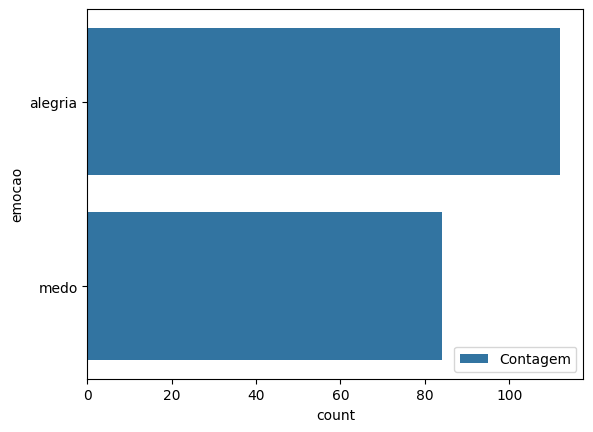

In [14]:
sns.countplot(y='emocao', data=base_dados, label = 'Contagem'); # verificar a quantidade de emoções

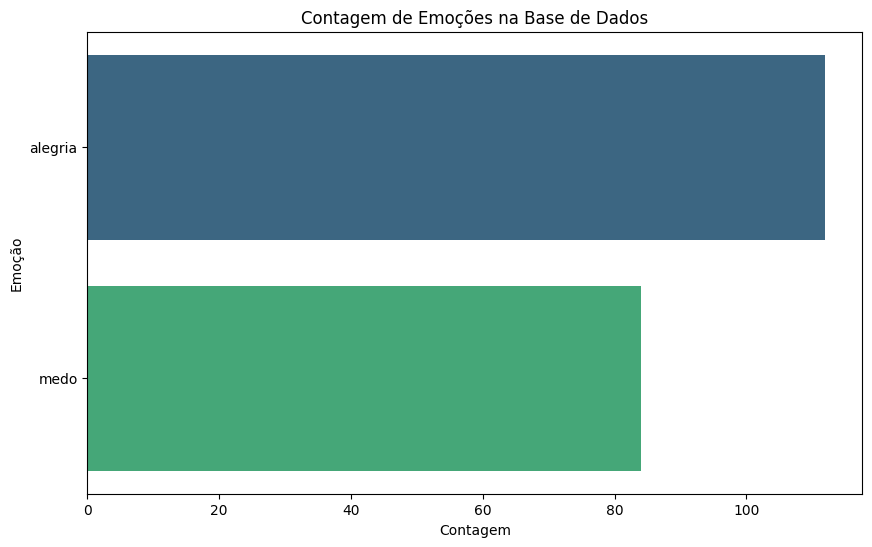

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt #

# Definindo uma paleta de cores qualitativa para garantir cores distintas para cada categoria
# 'viridis', 'plasma', 'pastel', 'Set1', 'tab10' são boas opções
PALETA = 'viridis' 


plt.figure(figsize=(10, 6)) # Opcional: define o tamanho da figura

sns.countplot(
    y='emocao', 
    data=base_dados, 
    palette=PALETA,  # paleta de cores, dando uma cor para cada 'emocao'
    hue='emocao',
    order=base_dados['emocao'].value_counts().index # Opcional: ordena as barras da maior para a menor
)

# Adiciona título e labels
plt.title('Contagem de Emoções na Base de Dados')
plt.xlabel('Contagem')
plt.ylabel('Emoção')

# Remove a chamada 'label = Contagem' que estava no código original (não tem função aqui)
# É melhor usar plt.xlabel() e plt.title()

plt.show(); # Exibe o gráfico

# 25.8) Pré Processamento do Texto 

### remoção de stopword e de pontuações. 

abaixo será removido os caractéres

In [16]:
pontuacoes = string.punctuation
pontuacoes

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

retirar palavras como preposições, 

In [17]:
from spacy.lang.pt.stop_words import STOP_WORDS
stop_words = STOP_WORDS

In [18]:
print(stop_words)

{'teu', 'ao', 'tu', 'dez', 'conhecida', 'meio', 'tentaram', 'pelas', 'dá', 'vós', 'além', 'nova', 'tens', 'apoio', 'segunda', 'doze', 'vem', 'dizer', 'no', 'mal', 'tiveram', 'numa', 'lugar', 'estive', 'tivestes', 'algo', 'quinta', 'mil', 'possível', 'toda', 'teve', 'novo', 'área', 'bom', 'sobre', 'coisa', 'fazes', 'próximo', 'sétima', 'vens', 'nosso', 'quem', 'para', 'esses', 'posso', 'é', 'obrigado', 'foste', 'outros', 'estiveste', 'entre', 'tivemos', 'nós', 'sua', 'cima', 'maioria', 'questão', 'suas', 'quer', 'oitava', 'outra', 'quatro', 'pouca', 'obrigada', 'ter', 'irá', 'nuns', 'bastante', 'dentro', 'quê', 'deste', 'porque', 'dos', 'mas', 'querem', 'local', 'baixo', 'longe', 'ainda', 'do', 'poderá', 'direita', 'estivestes', 'foi', 'naquela', 'ser', 'também', 'cujo', 'grupo', 'primeira', 'seria', 'quieta', 'estiveram', 'fora', 'aqui', 'daquela', 'porém', 'não', 'boa', 'vezes', 'aquilo', 'de', 'aqueles', 'usa', 'embora', 'tua', 'através', 'quarto', 'meu', 'fazia', 'tal', 'vez', 'exem

In [19]:
len(stop_words)

416

Modelo pln, com o processamento de linguagem natural. 

In [20]:
#pln = spacy.load('pt')
pln = spacy.load("pt_core_news_sm")

In [21]:
#modelo arregado
pln # classe: pacy.lang.pt.Portuguese

In [22]:
def preprocessamento_inicio(texto):
  texto = texto.lower()
  documento = pln(texto) # inserir os dados no modelo pln - processamento de linguagem natural. 

  lista = [] # inserir as palavras pré processadas
  for token in documento:
    lista.append(token.text) # retorna token por token

  return lista

teste = preprocessamento_inicio('Estou aprendendo processamento de linguagem natural, Curso em Curitiba')
teste
    

['estou',
 'aprendendo',
 'processamento',
 'de',
 'linguagem',
 'natural',
 ',',
 'curso',
 'em',
 'curitiba']

In [23]:
teste = preprocessamento_inicio('Estou aPrendendo 1 10 23 processamento de linguagem natural, Curso em Curitiba')
teste

['estou',
 'aprendendo',
 '1',
 '10',
 '23',
 'processamento',
 'de',
 'linguagem',
 'natural',
 ',',
 'curso',
 'em',
 'curitiba']

In [24]:
def preprocessamento(texto):
  texto = texto.lower()
  documento = pln(texto) # inserir os dados no modelo pln - processamento de linguagem natural. 

  lista = [] # inserir as palavras pré processadas
  for token in documento:
    lista.append(token.text) # retorna token por token
    #lista.append(token.lemma_)

  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
  lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

  return lista

In [25]:
teste = preprocessamento('Estou aprendendo processamento de linguagem natural, Curso em Curitiba')
teste

'aprendendo processamento linguagem natural curso curitiba'

In [26]:
teste = preprocessamento('Estou aPrendendo 1 10 23 processamento de linguagem natural, Curso em Curitiba')
teste

'aprendendo processamento linguagem natural curso curitiba'

In [27]:
def preprocessamento(texto):
  texto = texto.lower() # padronizar tudo como minúsculo. 
  documento = pln(texto) # inserir os dados no modelo pln - processamento de linguagem natural. 

  lista = [] # inserir as palavras pré processadas
  for token in documento:
    #lista.append(token.text) # retorna token por token
    lista.append(token.lemma_)
      
  print(f'retornar o lemma_ {lista}, antes de retirar pontuações e stop words')
  # iremos remover as palavras stop_words e as pontuações (caracteres). 
  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
  print(f'retirada/remoção pura:{lista}')
  # queremos também remover os tokens, ou seja os números 1, 10, 23 por exemplo.
  # verificar se é digito: isdigit
  lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

  return lista

teste = preprocessamento('Estou aPrendendo 1 10 23 processamento de linguagem natural, Curso em Curitiba')
teste

retornar o lemma_ ['estar', 'aprender', '1', '10', '23', 'processamento', 'de', 'linguagem', 'natural', ',', 'curso', 'em', 'curitber'], antes de retirar pontuações e stop words
retirada/remoção pura:['aprender', '1', '10', '23', 'processamento', 'linguagem', 'natural', 'curso', 'curitber']


'aprender processamento linguagem natural curso curitber'

In [28]:
teste = preprocessamento('Estou aprendendo processamento de linguagem natural, Curso em Curitiba')
teste # *testo final que será repassado à rede neural*

retornar o lemma_ ['estar', 'aprender', 'processamento', 'de', 'linguagem', 'natural', ',', 'curso', 'em', 'curitber'], antes de retirar pontuações e stop words
retirada/remoção pura:['aprender', 'processamento', 'linguagem', 'natural', 'curso', 'curitber']


'aprender processamento linguagem natural curso curitber'

In [29]:
for i in range(2):
    print(i)
    print('é digito:')
    print(str(i).isdigit())

0
é digito:
True
1
é digito:
True


# 25.9) spaCy 3 => Pré-processamento da base de dados

### Etapa 4: Pré-processamento da base de dados

### Limpeza dos textos

Passar a função do texto para a base de dados na base de treinamento.

In [30]:
base_dados.head(10)

,texto,emocao
0,este trabalho é agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você,alegria
5,adoro seu cabelo macio,alegria
6,adoro a cor dos seus olhos,alegria
7,somo tão amáveis um com o outro,alegria
8,sinto uma grande afeição por ele,alegria
9,quero agradar meus filhos,alegria


In [31]:
# aplicarei o pré-processamento feito na função anterior
# apply aplica a função
base_dados['texto'] = base_dados['texto'].apply(preprocessamento)

retornar o lemma_ ['este', 'trabalho', 'ser', 'agradável'], antes de retirar pontuações e stop words
retirada/remoção pura:['trabalho', 'agradável']
retornar o lemma_ ['gostar', 'de', 'ficar', 'em o', 'seu', 'aconchego'], antes de retirar pontuações e stop words
retirada/remoção pura:['gostar', 'ficar', 'em o', 'aconchego']
retornar o lemma_ ['fiz', 'o', 'adesão', 'a o', 'curso', 'hoje'], antes de retirar pontuações e stop words
retirada/remoção pura:['fiz', 'adesão', 'a o', 'curso', 'hoje']
retornar o lemma_ ['eu', 'ser', 'admirar', 'por', 'muito'], antes de retirar pontuações e stop words
retirada/remoção pura:['admirar']
retornar o lemma_ ['adorar', 'como', 'você'], antes de retirar pontuações e stop words
retirada/remoção pura:['adorar']
retornar o lemma_ ['adorar', 'seu', 'cabelo', 'macio'], antes de retirar pontuações e stop words
retirada/remoção pura:['adorar', 'cabelo', 'macio']
retornar o lemma_ ['adorar', 'o', 'cor', 'de o', 'seu', 'olho'], antes de retirar pontuações e stop

internamente percorre texto por texto e aplica a função

In [32]:
base_dados.head(10)

,texto,emocao
0,trabalho agradável,alegria
1,gostar ficar em o aconchego,alegria
2,fiz adesão a o curso hoje,alegria
3,admirar,alegria
4,adorar,alegria
5,adorar cabelo macio,alegria
6,adorar cor de o olho,alegria
7,somo amável outro,alegria
8,sinto afeição,alegria
9,querer agradar filho,alegria


# 26.0) spaCy 4 Tratamento 

### Tratamento da classe

In [33]:
exemplo_base_dados = [["este trabalho é agradável", {"ALEGRIA": True, "MEDO": False}],
                      ["este lugar continua assustador", {"ALEGRIA": False, "MEDO": True}]]

In [34]:
type(exemplo_base_dados) # observaremos a estrutura de dados, retorna uma lista

list

In [35]:
exemplo_base_dados[0]

['este trabalho é agradável', {'ALEGRIA': True, 'MEDO': False}]

In [36]:
exemplo_base_dados[0][0]

'este trabalho é agradável'

In [37]:
exemplo_base_dados[0][1]

{'ALEGRIA': True, 'MEDO': False}

In [38]:
type(exemplo_base_dados[0][1]) # tipo dicionário

dict

In [39]:
# faremos um reprocessamento na nossa base de dados

In [40]:
base_dados_final = [] # lista vazia
i = 0 # para controlar o loop, mas nem foi utilizado. 
for texto, emocao in zip(base_dados['texto'], base_dados['emocao']): # percorrer as variáveis 
  # | para colocar dois (2) atributos tem que colocar dentro do zip
  print(f'texto:{texto}, emoção:{emocao}')
  if emocao == 'alegria':
    dic = ({'ALEGRIA': True, 'MEDO': False})
  elif emocao == 'medo':
    dic = ({'ALEGRIA': False, 'MEDO': True})

  base_dados_final.append([texto, dic.copy()])

texto:trabalho agradável, emoção:alegria
texto:gostar ficar em o aconchego, emoção:alegria
texto:fiz adesão a o curso hoje, emoção:alegria
texto:admirar, emoção:alegria
texto:adorar, emoção:alegria
texto:adorar cabelo macio, emoção:alegria
texto:adorar cor de o olho, emoção:alegria
texto:somo amável outro, emoção:alegria
texto:sinto afeição, emoção:alegria
texto:querer agradar filho, emoção:alegria
texto:sinto completamente amar, emoção:alegria
texto:amar, emoção:alegria
texto:alívio, emoção:alegria
texto:dor amenizar finalmente, emoção:alegria
texto:achar apaixonar, emoção:alegria
texto:amar maravilhoso, emoção:alegria
texto:sentir animar, emoção:alegria
texto:sinto hoje, emoção:alegria
texto:luar belo, emoção:alegria
texto:dia bonito, emoção:alegria
texto:afortunar, emoção:alegria
texto:maravilha de o mundo, emoção:alegria
texto:recebi carinho hoje de o colega, emoção:alegria
texto:sentir reconfortar hoje, emoção:alegria
texto:amigo, emoção:alegria
texto:contente resultado de o teste

In [41]:
len(base_dados_final)

196

In [42]:
base_dados_final

[['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}],
 ['gostar ficar em o aconchego', {'ALEGRIA': True, 'MEDO': False}],
 ['fiz adesão a o curso hoje', {'ALEGRIA': True, 'MEDO': False}],
 ['admirar', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar cabelo macio', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar cor de o olho', {'ALEGRIA': True, 'MEDO': False}],
 ['somo amável outro', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto afeição', {'ALEGRIA': True, 'MEDO': False}],
 ['querer agradar filho', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto completamente amar', {'ALEGRIA': True, 'MEDO': False}],
 ['amar', {'ALEGRIA': True, 'MEDO': False}],
 ['alívio', {'ALEGRIA': True, 'MEDO': False}],
 ['dor amenizar finalmente', {'ALEGRIA': True, 'MEDO': False}],
 ['achar apaixonar', {'ALEGRIA': True, 'MEDO': False}],
 ['amar maravilhoso', {'ALEGRIA': True, 'MEDO': False}],
 ['sentir animar', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto hoje', {'ALEGRIA': Tr

In [43]:
base_dados_final[0]

['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}]

In [44]:
base_dados_final[0][0]

'trabalho agradável'

In [45]:
base_dados_final[0][1]

{'ALEGRIA': True, 'MEDO': False}

In [46]:
type(base_dados_final[0][1])

dict

In [47]:
# assim a base final já está pronto

# 26.1) Classificador - Rede Neural 

In [48]:
# inicializar o novo modelo 
from spacy.training import Example

In [49]:
# classificador e modelo da rede neural
modelo = spacy.blank('pt') # inicializar o modelo 

categorias = modelo.create_pipe('textcat') # categorização do texto
#categorizar a alegria e o medo
categorias.add_label("ALEGRIA") # indicar explicitamente o que há na base de dados 
categorias.add_label("MEDO") # adicionar 




1

In [50]:
textcat = modelo.add_pipe("textcat")

In [51]:
textcat

In [52]:
modelo = spacy.blank('pt') # inicializar o modelo <= classificador e modelo da rede neural

#categorias = modelo.create_pipe('textcat') # categorização do texto
textcat = modelo.add_pipe("textcat")
textcat.add_label("ALEGRIA") # indicar explicitamente o que há na base de dados 
textcat.add_label("MEDO") # adicionar 
historico = [] # armazenar os resultados, para depois gerar o gráfico

Continuação e treinamento 

#### 26.2) Continuação classificador RN

In [53]:
for batch in spacy.util.minibatch(base_dados_final, 30):
    print(batch)

[['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}], ['gostar ficar em o aconchego', {'ALEGRIA': True, 'MEDO': False}], ['fiz adesão a o curso hoje', {'ALEGRIA': True, 'MEDO': False}], ['admirar', {'ALEGRIA': True, 'MEDO': False}], ['adorar', {'ALEGRIA': True, 'MEDO': False}], ['adorar cabelo macio', {'ALEGRIA': True, 'MEDO': False}], ['adorar cor de o olho', {'ALEGRIA': True, 'MEDO': False}], ['somo amável outro', {'ALEGRIA': True, 'MEDO': False}], ['sinto afeição', {'ALEGRIA': True, 'MEDO': False}], ['querer agradar filho', {'ALEGRIA': True, 'MEDO': False}], ['sinto completamente amar', {'ALEGRIA': True, 'MEDO': False}], ['amar', {'ALEGRIA': True, 'MEDO': False}], ['alívio', {'ALEGRIA': True, 'MEDO': False}], ['dor amenizar finalmente', {'ALEGRIA': True, 'MEDO': False}], ['achar apaixonar', {'ALEGRIA': True, 'MEDO': False}], ['amar maravilhoso', {'ALEGRIA': True, 'MEDO': False}], ['sentir animar', {'ALEGRIA': True, 'MEDO': False}], ['sinto hoje', {'ALEGRIA': True, 'MEDO': False

In [54]:
for batch in spacy.util.minibatch(base_dados_final, 2):
    for texto, entities in batch:
       print(f'texto {texto}, entities: {entities}')
    print()

texto trabalho agradável, entities: {'ALEGRIA': True, 'MEDO': False}
texto gostar ficar em o aconchego, entities: {'ALEGRIA': True, 'MEDO': False}

texto fiz adesão a o curso hoje, entities: {'ALEGRIA': True, 'MEDO': False}
texto admirar, entities: {'ALEGRIA': True, 'MEDO': False}

texto adorar, entities: {'ALEGRIA': True, 'MEDO': False}
texto adorar cabelo macio, entities: {'ALEGRIA': True, 'MEDO': False}

texto adorar cor de o olho, entities: {'ALEGRIA': True, 'MEDO': False}
texto somo amável outro, entities: {'ALEGRIA': True, 'MEDO': False}

texto sinto afeição, entities: {'ALEGRIA': True, 'MEDO': False}
texto querer agradar filho, entities: {'ALEGRIA': True, 'MEDO': False}

texto sinto completamente amar, entities: {'ALEGRIA': True, 'MEDO': False}
texto amar, entities: {'ALEGRIA': True, 'MEDO': False}

texto alívio, entities: {'ALEGRIA': True, 'MEDO': False}
texto dor amenizar finalmente, entities: {'ALEGRIA': True, 'MEDO': False}

texto achar apaixonar, entities: {'ALEGRIA': True,

In [55]:
historico = [] # armazenar os resultados, para depois gerar o gráfico
# treinamento => com o ajuste dos pesos
#modelo.begin_training()
#for epoca in range(1000): # algoritmo executado por várias épocas, mil vezes
  #shuffle => mistura os dados que estão na nossa base de dados
  # início alegria e depois medo, temos que misturar
 # random.shuffle(base_dados_final)
 # losses = {} # losses é para controlar o erro.
  # batch lote
  ## valor 30, mas pode ser qualquer valor, é de quanto em quanto os registros são feito para fazer a atualização dos pesos. 
 # for batch in spacy.util.minibatch(base_dados_final, 30):
 #   textos = [modelo(texto) for texto, entities in batch]
 #   annotations = [{'cats': entities} for texto, entities in batch] # cats categoria, com a categoria ALEGRIA e MEDO.

   # modelo.update(textos,annotations, losses=losses) # atualização será feita com update. para de funcionar desta maneira apenas
  #if epoca % 100 == 0:
  #  print(f' época: {epoca}, com sua losses')
  #  print(losses)
  #  historico.append(losses)


In [56]:
historico = [] # armazenar os resultados, para depois gerar o gráfico
# treinamento => com o ajuste dos pesos
modelo.begin_training()
for epoca in range(1000): # algoritmo executado por várias épocas, mil vezes
  #shuffle => mistura os dados que estão na nossa base de dados
  # início alegria e depois medo, temos que misturar
  random.shuffle(base_dados_final)
  losses = {} # losses é para controlar o erro.
  # batch lote
  ## valor 30, mas pode ser qualquer valor, é de quanto em quanto os registros são feito para fazer a atualização dos pesos. 
  for batch in spacy.util.minibatch(base_dados_final, 30):
    textos = [modelo(texto) for texto, entities in batch]
    annotations = [{'cats': entities} for texto, entities in batch] # cats categoria, com a categoria ALEGRIA e MEDO.
    examples = [Example.from_dict(doc, annotation) for doc, annotation in zip(
            textos, annotations
        )]
    modelo.update(examples, losses=losses) # atualização será feita com update. 
  if epoca % 100 == 0:
    print(f' época: {epoca}, com sua losses')
    print(losses)
    historico.append(losses)


 época: 0, com sua losses
{'textcat': 1.7116698622703552}
 época: 100, com sua losses
{'textcat': 2.8119304410975654e-11}
 época: 200, com sua losses
{'textcat': 3.6808813917883765e-12}
 época: 300, com sua losses
{'textcat': 9.616354546969526e-13}
 época: 400, com sua losses
{'textcat': 3.4635129779383295e-13}
 época: 500, com sua losses
{'textcat': 1.5495595919004816e-13}
 época: 600, com sua losses
{'textcat': 6.390759232574594e-14}
 época: 700, com sua losses
{'textcat': 3.312674473009939e-14}
 época: 800, com sua losses
{'textcat': 1.8596215333680638e-14}
 época: 900, com sua losses
{'textcat': 8.193493429694084e-15}


196 registros /30 = 6,5 ~7 teremos 7 batch, e em cada batch teremos 30 registros. 

calcula o erro e ajusta os pesos

o objetivo é diminuir o valor do erro. 

In [57]:
len(base_dados_final)/30, round(len(base_dados_final)/30,0)

(6.533333333333333, 7.0)

In [58]:
2%100

2

In [59]:
for epoca in range(1000):
    if epoca % 100 == 0:
        print(epoca)
    

0
100
200
300
400
500
600
700
800
900


In [60]:
historico

[{'textcat': 1.7116698622703552},
 {'textcat': 2.8119304410975654e-11},
 {'textcat': 3.6808813917883765e-12},
 {'textcat': 9.616354546969526e-13},
 {'textcat': 3.4635129779383295e-13},
 {'textcat': 1.5495595919004816e-13},
 {'textcat': 6.390759232574594e-14},
 {'textcat': 3.312674473009939e-14},
 {'textcat': 1.8596215333680638e-14},
 {'textcat': 8.193493429694084e-15}]

In [61]:
# adicionaremos o dicionário: get('textcat')

historico_loss = []
for i in historico:
  historico_loss.append(i.get('textcat'))
    

In [62]:
historico_loss

[1.7116698622703552,
 2.8119304410975654e-11,
 3.6808813917883765e-12,
 9.616354546969526e-13,
 3.4635129779383295e-13,
 1.5495595919004816e-13,
 6.390759232574594e-14,
 3.312674473009939e-14,
 1.8596215333680638e-14,
 8.193493429694084e-15]

In [63]:
# teremos apenas os valores para plotar no gráfico

historico_loss = np.array(historico_loss)
historico_loss

array([1.71166986e+00, 2.81193044e-11, 3.68088139e-12, 9.61635455e-13,
       3.46351298e-13, 1.54955959e-13, 6.39075923e-14, 3.31267447e-14,
       1.85962153e-14, 8.19349343e-15])

Text(0, 0.5, 'Erro')

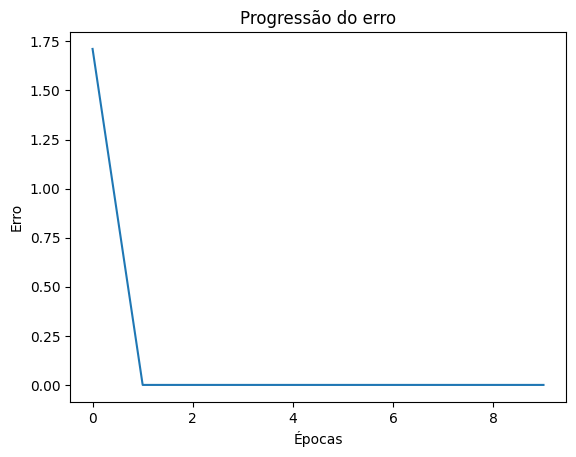

In [64]:
# acompanhar a diminuição do erro. 
import matplotlib.pyplot as plt
plt.plot(historico_loss)
plt.title('Progressão do erro')
plt.xlabel('Épocas')
plt.ylabel('Erro')

não precisa fazer  treinamento com tantas épocas, pelo gráfico, com épocas de quase 200 épocas (etre 0 e 2 no eixo x épocas) já é suficiente, pois há uma estabilização do erro conforme o gráfico.

Base para ver até quantas épocas treinamos o nosso modelo.

In [65]:
# modelo para salvar no disco, 
modelo.to_disk("modelo_spacy") #salvo em uma pasta no computador

In [66]:
# próximo passamos uma frase e terá classificação, medo ou alegria. 

### 26.3) idicativo das frases através dos modelos

# Etapa 6: Testes com uma frase

In [67]:
# carregando o modelo, salvando o arquivo na memória
modelo_carregado = spacy.load("modelo_spacy")
modelo_carregado